# Cross-contour transport

This notebook calculates the transport across an arbitrary contour. To do so we need a contour, such as sea surface height or bathymetry, together with some masks to indicate which direction is across the contour at each position along the contour. This is calculated in Create_contour.ipnyb and we can simply load in that information. We then load the transport data and compute the transport, resulting in data with dimensions depth and along contour index. 

Computation times shown used conda environment `analysis3-26.06` on 28 broadwell cpus.

**Alert:** After including the additional cases the contour number doesn't always monotonically increase along the contour. At the moment, the two indices that are set at the same time are adjacent numbers, whereas if you were following the contour you'd expect their numbers to be 2 apart with the other coordinate in between. See  https://github.com/COSIMA/cosima-recipes/issues/383.

First, we load useful packages:

In [5]:
import pandas as pd
import intake
import dask
import matplotlib.pyplot as plt
import netCDF4 as nc
import xarray as xr
import numpy as np
import cmocean

from dask.distributed import Client

catalog = intake.cat.access_nri

In [2]:
client = Client(threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43599 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/43599/status,
Dashboard: /proxy/43599/status,Workers: 28
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40909,Workers: 0
Dashboard: /proxy/43599/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39291,Total threads: 1
Dashboard: /proxy/39485/status,Memory: 4.47 GiB
Nanny: tcp://127.0.0.1:44169,


2026-07-02 11:16:53,475 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 304a50fd35aeae60b856608b835cf9c7 initialized by task ('rechunk-merge-rechunk-transfer-a5fbad34ed33911b1a5851526b0b332d', 0, 0, 0, 4, 0, 2, 0, 4) executed on worker tcp://127.0.0.1:38835
2026-07-02 11:16:54,343 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 21f70afe2b90ba1337f292be51cc5b0c initialized by task ('rechunk-merge-rechunk-transfer-a5fbad34ed33911b1a5851526b0b332d', 0, 0, 0, 3, 1, 5, 0, 3) executed on worker tcp://127.0.0.1:39291
2026-07-02 11:16:54,430 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle fd472274b34e1f6c0ba4ffb568efda31 initialized by task ('rechunk-merge-rechunk-transfer-a5fbad34ed33911b1a5851526b0b332d', 0, 0, 0, 2, 1, 5, 0, 2) executed on worker tcp://127.0.0.1:42693
2026-07-02 11:16:55,382 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 2e0068bca84594790796bdb6251c19a7 initialized by task ('rechunk-merge-rechunk-transfer-a5fbad34ed33911b1a58

### Choose experiment

In [6]:
experiment = '01deg_jra55v13_ryf9091'

start_time = '2170-01-01'
end_time = '2170-12-31'
time_slice = slice(start_time, end_time)

### Load grid information

In [7]:
ht = catalog[experiment].search(variable="ht", frequency="fx").to_dask().ht
hu = catalog[experiment].search(variable="hu", frequency="fx").to_dask().hu

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


#### Choose a latitude range.

We must make sure that this latitude range is so that the t-cells are always south and west of the u-cells.¶

This is important because the meridional and zonal transports occur on different grids to each other. We can check this by loading the u-cell and t-cell coordinates. 

This is important when selecting the contour, see Create_contour.ipynb.

In [8]:
lat_range = slice(-82, -59)

### Load contour information

In [10]:
slope_contour = xr.open_dataset('/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc')

In [11]:
slope_contour

<xarray.Dataset> Size: 38MB
Dimensions:                    (yh: 533, xq: 3600, yq: 533, xh: 3600)
Coordinates:
  * yh                         (yh) float64 4kB -79.0 -78.95 ... -55.12 -55.07
  * xq                         (xq) float64 29kB -279.9 -279.8 ... 79.9 80.0
  * yq                         (yq) float64 4kB -78.98 -78.93 ... -55.1 -55.04
  * xh                         (xh) float64 29kB -279.9 -279.8 ... 79.85 79.95
Data variables:
    mask_x_transport           (yh, xq) float32 8MB ...
    mask_y_transport           (yq, xh) float32 8MB ...
    mask_x_transport_numbered  (yh, xq) float32 8MB ...
    mask_y_transport_numbered  (yq, xh) float32 8MB ...
    contour_masked_above       (yh, xh) float32 8MB ...

And plot just to confirm that we are happy with the chosen contour.

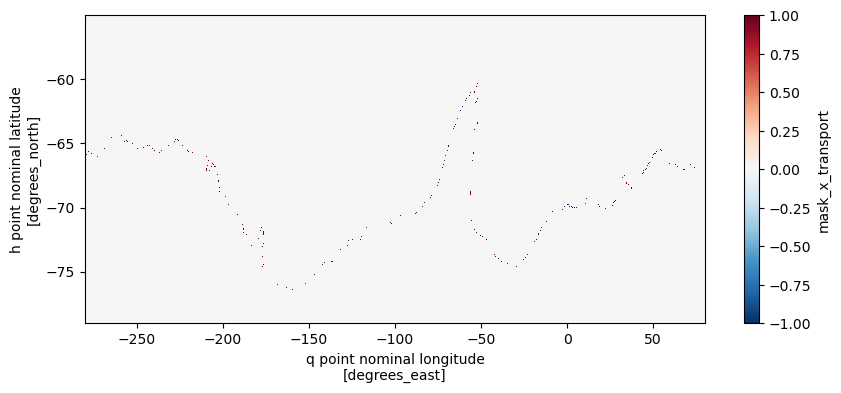

In [14]:
fig = plt.figure(figsize = (10, 4))

slope_contour.mask_x_transport.plot();

As can be seen, in `mask_x_transport` there is red (+1) where eastward transport crosses the contour, and blue (-1) where westward transport crosses the contour (in the net northward direction). There are zeros everywhere else.

#### We now have the coordinates of the contours, and whether the x or y transport is needed to calculate cross-contour transport.

Set the dimension name to always be simply latitude/longitude irrespective of the variable to make concatenation of transports in both direction and sorting possible.

In [23]:
mask_x_transport = slope_contour.mask_x_transport.rename({'yh': 'latitude', 'xq': 'longitude'})
mask_y_transport = slope_contour.mask_y_transport.rename({'yq': 'latitude', 'xh': 'longitude'})
mask_x_transport_numbered = slope_contour.mask_x_transport_numbered.rename({'yh': 'latitude', 'xq': 'longitude'})
mask_y_transport_numbered = slope_contour.mask_y_transport_numbered.rename({'yq': 'latitude', 'xh': 'longitude'})

#### Stack contour data into 1D

Create the contour order data-array. Note that in this procedure the x-grid counts have x-grid dimensions and the y-grid counts have y-grid dimensions, but these are implicit, the dimension  *names* are kept general across the counts, the generic latitude, longitude, so that concatening works but we dont double up with numerous counts for one lat/lon point.


In [27]:
# stack contour data into 1d:
mask_x_numbered_1d = mask_x_transport_numbered.stack(contour_index = ['latitude', 'longitude'])
mask_x_numbered_1d = mask_x_numbered_1d.where(mask_x_numbered_1d > 0, drop = True)

mask_y_numbered_1d = mask_y_transport_numbered.stack(contour_index = ['latitude', 'longitude'])
mask_y_numbered_1d = mask_y_numbered_1d.where(mask_y_numbered_1d > 0, drop = True)

contour_ordering = xr.concat((mask_x_numbered_1d, mask_y_numbered_1d), dim = 'contour_index')
contour_ordering = contour_ordering.sortby(contour_ordering)
contour_index_array = np.arange(1, len(contour_ordering)+1)

#### Load transports `tx_trans` and `ty_trans`

In [28]:
cat_subset = catalog[experiment]
var_search = cat_subset.search(variable='ty_trans', frequency="1mon")  # Can get 1mon or 3mon data
dset = var_search.to_dask(xarray_open_kwargs={'decode_timedelta' : False})
darray = dset['ty_trans']
darray = darray.sel(time=slice(start_time, end_time))
ty_trans = darray
ty_trans = ty_trans.sel(yu_ocean = lat_range, time = time_slice)
ty_trans.chunk(chunks={"time": -1})
ty_trans

<xarray.DataArray 'ty_trans' (time: 12, st_ocean: 75, yu_ocean: 510,
                              xt_ocean: 3600)> Size: 7GB
dask.array<getitem, shape=(12, 75, 510, 3600), dtype=float32, chunksize=(2, 14, 510, 800), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) object 96B 2170-01-16 12:00:00 ... 2170-12-16 12:00:00
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * yu_ocean  (yu_ocean) float64 4kB -81.09 -81.05 -81.0 ... -59.06 -59.01
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
Attributes:
    long_name:      T-cell j-mass transport
    units:          kg/s
    valid_range:    [-1.e+20  1.e+20]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  ocean_mass_y_transport

These data aren't enourmous (just over 6GB), but they're not chunked very intelligently - having lots of little chunks increases multiprocessing overhead costs. We want chunks in the 100MB - 1GB range (probably towards the lower end of that range). We want to make computations, such as averaging, along the time axis, so it makes sense to keep all the time data for any position together in a chunk. However, because the input files consist of one time-step per file, we couldn't do this at load time. However, now that the data are loaded, we can do it after the fact: 

In [29]:
ty_trans = ty_trans.chunk(chunks={"time": -1, "st_ocean": -1, "yu_ocean": 102, "xt_ocean": 400})
ty_trans

<xarray.DataArray 'ty_trans' (time: 12, st_ocean: 75, yu_ocean: 510,
                              xt_ocean: 3600)> Size: 7GB
dask.array<rechunk-p2p, shape=(12, 75, 510, 3600), dtype=float32, chunksize=(12, 75, 102, 400), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) object 96B 2170-01-16 12:00:00 ... 2170-12-16 12:00:00
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * yu_ocean  (yu_ocean) float64 4kB -81.09 -81.05 -81.0 ... -59.06 -59.01
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
Attributes:
    long_name:      T-cell j-mass transport
    units:          kg/s
    valid_range:    [-1.e+20  1.e+20]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  ocean_mass_y_transport

Now that we've worked out our chunking schema, we'll apply it to `tx_trans` as well.

In [30]:
cat_subset = catalog[experiment]
var_search = cat_subset.search(variable='tx_trans', frequency="1mon")
dset = var_search.to_dask(xarray_open_kwargs={'decode_timedelta' : False})
darray = dset['tx_trans']
darray = darray.sel(time=slice(start_time, end_time))
tx_trans = darray
tx_trans = tx_trans.sel(yt_ocean = lat_range, time = time_slice)
tx_trans = tx_trans.chunk(chunks={"time": -1, "st_ocean": -1, "yt_ocean": 102, "xu_ocean": 400})

ty_trans = ty_trans.rename({'yu_ocean': 'latitude', 'xt_ocean': 'longitude'})
tx_trans = tx_trans.rename({'yt_ocean': 'latitude', 'xu_ocean': 'longitude'})

tx_trans

<xarray.DataArray 'tx_trans' (time: 12, st_ocean: 75, latitude: 510,
                              longitude: 3600)> Size: 7GB
dask.array<rechunk-p2p, shape=(12, 75, 510, 3600), dtype=float32, chunksize=(12, 75, 102, 400), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 96B 2170-01-16 12:00:00 ... 2170-12-16 12:00:00
  * st_ocean   (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * latitude   (latitude) float64 4kB -81.11 -81.07 -81.02 ... -59.08 -59.03
  * longitude  (longitude) float64 29kB -279.9 -279.8 -279.7 ... 79.8 79.9 80.0
Attributes:
    long_name:      T-cell i-mass transport
    units:          kg/s
    valid_range:    [-1.e+20  1.e+20]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  ocean_mass_x_transport

#### Take time average

In [31]:
%%time

# weighed time mean by month length
days_in_month = ty_trans.time.dt.days_in_month
days_in_year = 365

tx_trans = (tx_trans * days_in_month / days_in_year).sum('time')
tx_trans = tx_trans.load()

ty_trans = (ty_trans * days_in_month / days_in_year).sum('time')
ty_trans = ty_trans.load()

CPU times: user 16.8 s, sys: 13.5 s, total: 30.2 s
Wall time: 31.6 s


#### Convert from mass transport to volume transport

In [32]:
ρ0 = 1035 # kg/m^3

ty_trans = ty_trans * mask_y_transport / ρ0 # convert kg/s -> m^3/s
tx_trans = tx_trans * mask_x_transport / ρ0 # convert kg/s -> m^3/s

#### Extract transport values along contour

In [33]:
## We could also loop in time if we didn't want the time average. 
# In that case, initialise a data array and fill in data by looping in time.

# stack transports into 1d and drop any points not on contour:
x_transport_1d = tx_trans.stack(contour_index = ['latitude', 'longitude'])
x_transport_1d = x_transport_1d.where(mask_x_numbered_1d>0, drop = True)
y_transport_1d = ty_trans.stack(contour_index = ['latitude', 'longitude'])
y_transport_1d = y_transport_1d.where(mask_y_numbered_1d>0, drop = True)

# combine all points on contour:
vol_trans_across_contour = xr.concat((x_transport_1d, y_transport_1d), dim = 'contour_index')
vol_trans_across_contour = vol_trans_across_contour.sortby(contour_ordering)
vol_trans_across_contour.coords['contour_index'] = contour_index_array
vol_trans_across_contour = vol_trans_across_contour.load()

/jobfs/172825254.gadi-pbs/ipykernel_101579/2814091809.py:13: FutureWarning: updating coordinate 'contour_index', which is a PandasMultiIndex, would leave the multi-index level coordinates ['latitude', 'longitude'] in an inconsistent state. This will raise an error in the future. Use `.drop_vars(['contour_index', 'latitude', 'longitude'])` to drop the coordinates' values before assigning new coordinate values.
  vol_trans_across_contour.coords['contour_index'] = contour_index_array


Plot the cumulative transport along the contour, summed over the lower part of the water column.
We can clearly see the northward dense water export in the Ross and Weddell Seas.


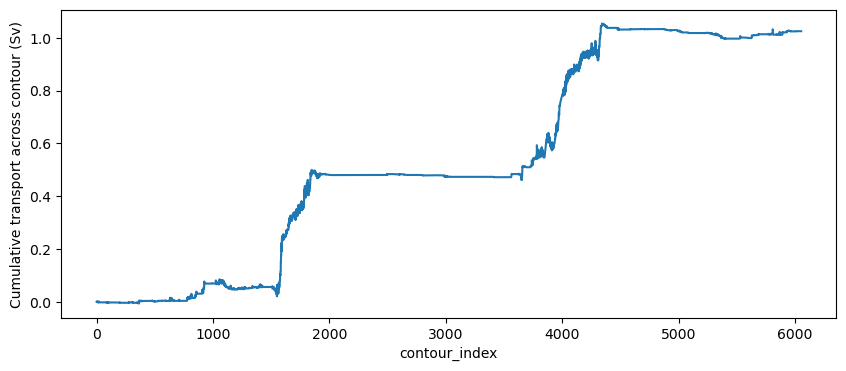

In [34]:
plt.figure(1, figsize=(10, 4))

(vol_trans_across_contour.sel(st_ocean=slice(800, 6000)).sum('st_ocean').cumsum('contour_index')/1e6).plot()
plt.ylabel('Cumulative transport across contour (Sv)');  

#### Finally, we can extract the coordinates of the contour index, and the distance, for a more meaningful $x$ axis.

In [35]:
contour_ordering = xr.concat((mask_x_numbered_1d, mask_y_numbered_1d), dim = 'contour_index')
contour_ordering = contour_ordering.sortby(contour_ordering)

# get lat and lon along contour, useful for plotting later:
lat_along_contour = contour_ordering.latitude.copy()
lon_along_contour = contour_ordering.longitude.copy()

contour_index_array = np.arange(1, len(contour_ordering)+1)

# don't need the multi-index anymore, replace with contour count and save
lat_along_contour.coords['contour_index'] = contour_index_array
lon_along_contour.coords['contour_index'] = contour_index_array

/jobfs/172825254.gadi-pbs/ipykernel_101579/3395851563.py:11: FutureWarning: updating coordinate 'contour_index', which is a PandasMultiIndex, would leave the multi-index level coordinates ['latitude', 'longitude'] in an inconsistent state. This will raise an error in the future. Use `.drop_vars(['contour_index', 'latitude', 'longitude'])` to drop the coordinates' values before assigning new coordinate values.
  lat_along_contour.coords['contour_index'] = contour_index_array
/jobfs/172825254.gadi-pbs/ipykernel_101579/3395851563.py:12: FutureWarning: updating coordinate 'contour_index', which is a PandasMultiIndex, would leave the multi-index level coordinates ['latitude', 'longitude'] in an inconsistent state. This will raise an error in the future. Use `.drop_vars(['contour_index', 'latitude', 'longitude'])` to drop the coordinates' values before assigning new coordinate values.
  lon_along_contour.coords['contour_index'] = contour_index_array


#### Extract distance in between contour coordinates
This is used to label the x-axis in the plots below. Note these distances don't exactly match the dxt / dyt variables in the model, but it's only used for plotting, so it's probably ok.

In [36]:
from geopy import distance

num_points = len(lat_along_contour)
d_distance_along_contour = np.zeros((num_points))

for i in range(num_points-1):
    d_distance_along_contour[i+1] = distance.distance((lat_along_contour[i], lon_along_contour[i]), (lat_along_contour[i+1], lon_along_contour[i+1])).km

distance_along_contour = np.cumsum(d_distance_along_contour)

#### Select the indices for axis labels of specific longitudes, so we can plot transport vs distance but have longitude labels instead of length

In [37]:
target_lons = [-280, -240, -180, -120, -60, 0, 6., 80]

distance_indices = np.zeros_like(target_lons)

for j, lon in enumerate(target_lons):
    distance_indices[j] = np.argmin(np.abs((lon_along_contour.values - lon)))

#### Plot cumulative transport against distance along the contour.

In [40]:
contour_depth = 1000
depth_to_integrate = 800 # m

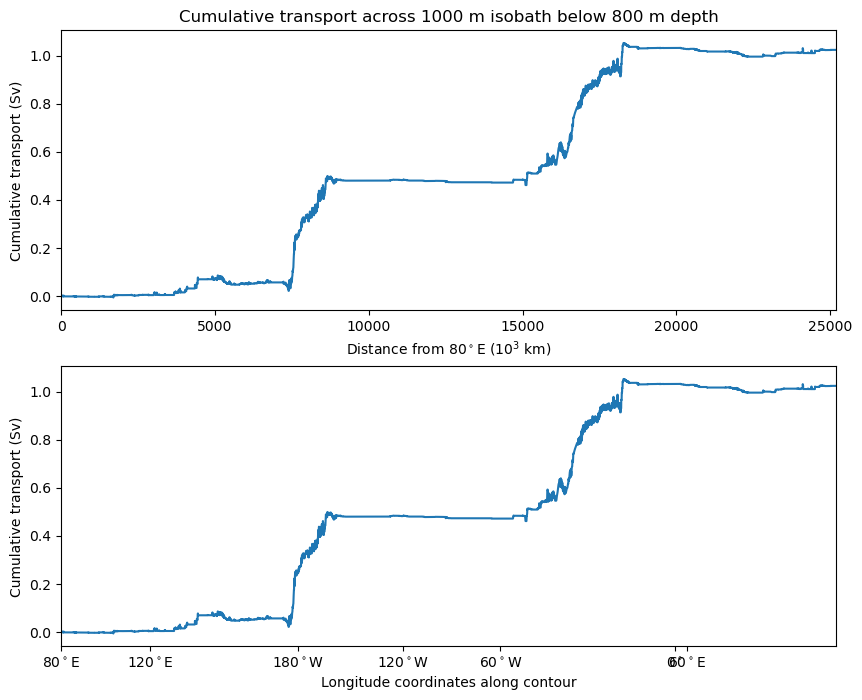

In [41]:
fig, axes = plt.subplots(nrows = 2, figsize = (10, 8))

# factor 1e-6 converts m^3/s -> Sv
axes[0].plot(distance_along_contour, (1e-6 * vol_trans_across_contour.sel(st_ocean = slice(depth_to_integrate, 6000)).sum('st_ocean').cumsum('contour_index')))

axes[0].set_ylabel('Cumulative transport (Sv)')
axes[0].set_xlabel('Distance from 80$^\circ$E (10$^3$ km)')
axes[0].set_xlim(0, distance_along_contour[-1])
axes[0].set_title(f'Cumulative transport across {contour_depth} m isobath below {depth_to_integrate} m depth')

# factor 1e-6 converts m^3/s -> Sv
axes[1].plot(distance_along_contour, (1e-6 * vol_trans_across_contour.sel(st_ocean = slice(depth_to_integrate, 6000)).sum('st_ocean').cumsum('contour_index')))

axes[1].set_xticks(distance_along_contour[distance_indices.astype(int)[:-1]])
axes[1].set_xticklabels(('80$^\circ$E', '120$^\circ$E', '180$^\circ$W', '120$^\circ$W', '60$^\circ$W', '0$^\circ$', '60$^\circ$E'))
axes[1].set_xlim(0, distance_along_contour[-1])

axes[1].set_xlabel('Longitude coordinates along contour')
axes[1].set_ylabel('Cumulative transport (Sv)');

We can see that there is a net northward transport across the 1000m isobath on the Antarctic continental slope. This is spatially localised near the Ross and Weddell Seas where dense water is formed and exported. We could then choose to extract the density (or salt and temperature) along this same path, do this by interpolating density to the north and eastern edge of t-cells. Then we could bin the transports in each depth level into the corresponding density, to determine the transport across the contour in density space. Note this density binning needs to be done online or using at least daily data. An example of this calculation can be found in https://github.com/claireyung/Topographic_Hotspots_Upwelling-Paper_Code/blob/main/Analysis_Code/Save_and_bin_along_contours.ipynb. 